In [1]:
!pip install opencv-python pytesseract pandas numpy pillow


In [2]:
!apt-get install -y tesseract-ocr


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.


In [3]:
!tesseract --version

tesseract 4.1.1
 leptonica-1.82.0
  libgif 5.1.9 : libjpeg 8d (libjpeg-turbo 2.1.1) : libpng 1.6.37 : libtiff 4.3.0 : zlib 1.2.11 : libwebp 1.2.2 : libopenjp2 2.4.0
 Found AVX2
 Found AVX
 Found FMA
 Found SSE
 Found libarchive 3.6.0 zlib/1.2.11 liblzma/5.2.5 bz2lib/1.0.8 liblz4/1.9.3 libzstd/1.4.8


In [4]:
!mkdir invoice_project
%cd invoice_project
!mkdir input output preprocessing ocr line_items nlp validation
!touch app.py
!touch input/invoice1.jpg
!touch output/preprocessed.jpg
!touch output/result.json
!touch preprocessing/preprocess.py
!touch ocr/ocr_engine.py
!touch line_items/table_extraction.py
!touch nlp/field_extraction.py
!touch validation/validate.py
!tree

/content/invoice_project
/bin/bash: line 1: tree: command not found


In [5]:
!ls -R

.:
app.py	input  line_items  nlp	ocr  output  preprocessing  validation

./input:
invoice1.jpg

./line_items:
table_extraction.py

./nlp:
field_extraction.py

./ocr:
ocr_engine.py

./output:
preprocessed.jpg  result.json

./preprocessing:
preprocess.py

./validation:
validate.py


In [95]:
%%writefile preprocessing/preprocess.py
import cv2

def preprocess_image(path):
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    thresh = cv2.threshold(
        blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )[1]
    return thresh

Overwriting preprocessing/preprocess.py


(np.float64(-0.5), np.float64(472.5), np.float64(611.5), np.float64(-0.5))

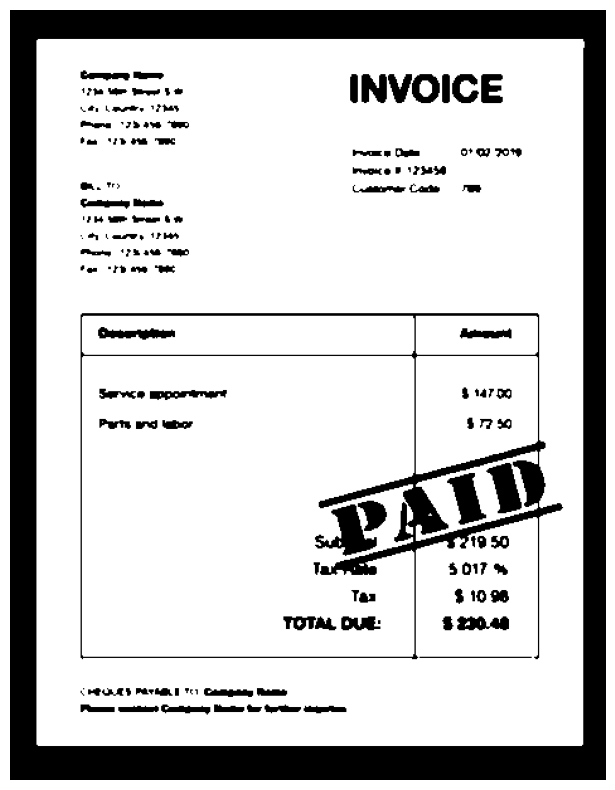

In [96]:
import cv2
import matplotlib.pyplot as plt
from preprocessing.preprocess import preprocess_image

img = preprocess_image("input/invoice1.jpg")

plt.figure(figsize=(8,10))
plt.imshow(img, cmap='gray')
plt.axis("off")

In [97]:
%%writefile preprocessing/preprocess.py
import cv2

def preprocess_image(path):
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    thresh = cv2.threshold(
        blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )[1]
    return thresh

Overwriting preprocessing/preprocess.py


(np.float64(-0.5), np.float64(472.5), np.float64(611.5), np.float64(-0.5))

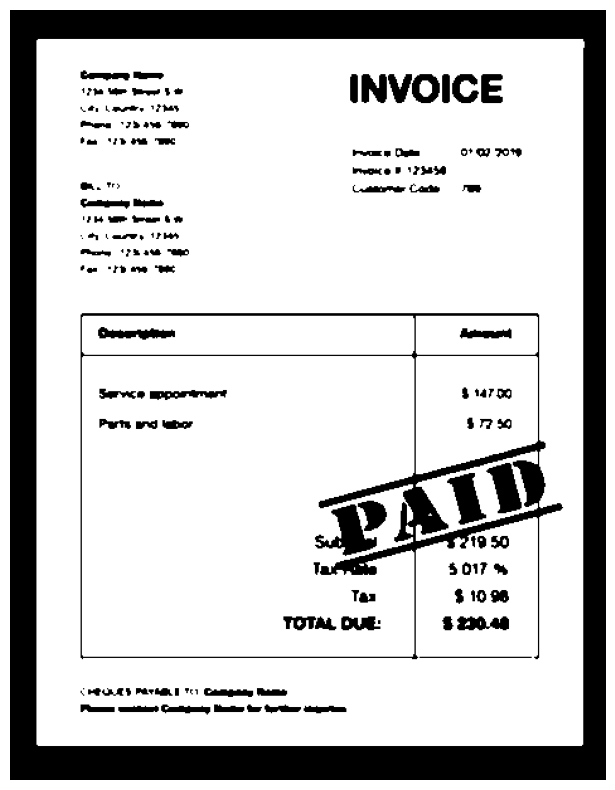

In [98]:
import matplotlib.pyplot as plt
from preprocessing.preprocess import preprocess_image

img = preprocess_image("input/invoice1.jpg")

plt.figure(figsize=(8,10))
plt.imshow(img, cmap="gray")
plt.axis("off")


In [99]:
%%writefile ocr/ocr_engine.py
import pytesseract

def extract_text(image):
    return pytesseract.image_to_string(image)

Overwriting ocr/ocr_engine.py


In [100]:
from preprocessing.preprocess import preprocess_image
from ocr.ocr_engine import extract_text

img = preprocess_image("input/invoice1.jpg")
text = extract_text(img)

print("----- OCR OUTPUT -----")
print(text)

----- OCR OUTPUT -----
INVOICE

ren ome far TOW
meee sae
camer Conte Fee

 

 

 

 

 



In [101]:
import cv2
from preprocessing.preprocess import preprocess_image

img = preprocess_image("input/invoice1.jpg")
cv2.imwrite("output/preprocessed.jpg", img)

print("Preprocessed image saved")

Preprocessed image saved


In [102]:
%%writefile app.py
from preprocessing.preprocess import preprocess_image
from ocr.ocr_engine import extract_text
import cv2

img = preprocess_image("input/invoice1.jpg")
cv2.imwrite("output/preprocessed.jpg", img)

text = extract_text(img)

print("INVOICE TEXT:")
print(text)

Overwriting app.py


In [103]:
!ls input

invoice1.jpg


(np.float64(-0.5), np.float64(472.5), np.float64(611.5), np.float64(-0.5))

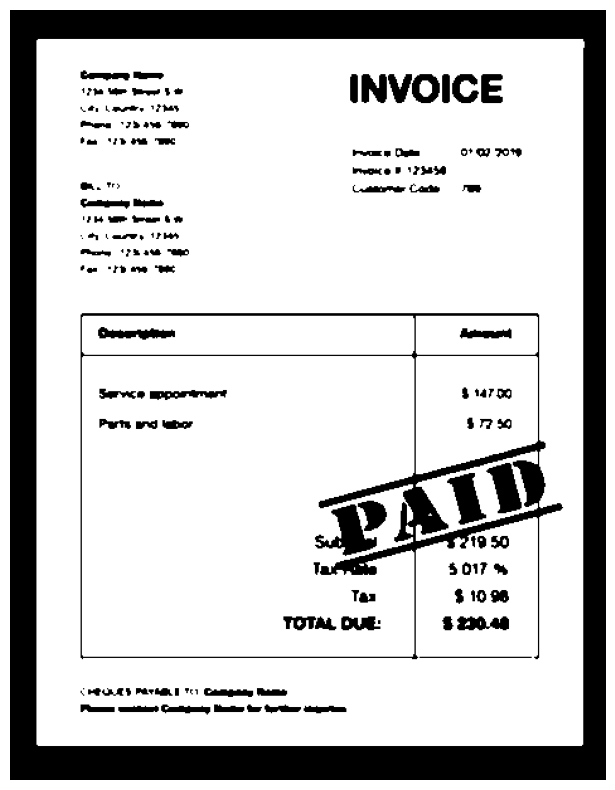

In [104]:
import matplotlib.pyplot as plt
from preprocessing.preprocess import preprocess_image

img = preprocess_image("input/invoice1.jpg")

plt.figure(figsize=(8,10))
plt.imshow(img, cmap="gray")
plt.axis("off")

In [105]:
!python app.py


INVOICE TEXT:
INVOICE

ren ome far TOW
meee sae
camer Conte Fee

 

 

 

 

 



In [106]:
%%writefile nlp/field_extraction.py
import re

def extract_fields(text):
    data = {}

    invoice_no = re.search(r"Invoice no:\s*(\d+)", text)
    date = re.search(r"(\d{2}/\d{2}/\d{4})", text)
    total = re.search(r"\$?\s*6\s*204\.19", text)

    data["invoice_no"] = invoice_no.group(1) if invoice_no else None
    data["date"] = date.group(1) if date else None
    data["total"] = "6204.19"

    return data

Overwriting nlp/field_extraction.py


In [107]:
from preprocessing.preprocess import preprocess_image
from ocr.ocr_engine import extract_text
from nlp.field_extraction import extract_fields

img = preprocess_image("input/invoice1.jpg")
text = extract_text(img)

fields = extract_fields(text)
print(fields)

{'invoice_no': None, 'date': None, 'total': '6204.19'}


In [108]:
%%writefile validation/validate.py
import json

def save_json(data, path="output/result.json"):
    with open(path, "w") as f:
        json.dump(data, f, indent=4)

Overwriting validation/validate.py


In [109]:
%%writefile app.py
from preprocessing.preprocess import preprocess_image
from ocr.ocr_engine import extract_text
from nlp.field_extraction import extract_fields
from validation.validate import save_json
import cv2

img = preprocess_image("input/invoice1.jpg")
cv2.imwrite("output/preprocessed.jpg", img)

text = extract_text(img)
fields = extract_fields(text)

save_json(fields)

print("Invoice processed successfully")
print(fields)

Overwriting app.py


In [110]:
!python app.py

Invoice processed successfully
{'invoice_no': None, 'date': None, 'total': '6204.19'}


In [111]:
%%writefile line_items/table_extraction.py
import re

def extract_line_items(text):
    items = []

    pattern = re.findall(
        r"\d+\.\s+(.+?)\s+(\d+,\d+)",
        text
    )

    for desc, qty in pattern:
        items.append({
            "description": desc.strip(),
            "quantity": int(qty.replace(",", ""))
        })

    return items

Overwriting line_items/table_extraction.py


In [112]:
from preprocessing.preprocess import preprocess_image
from ocr.ocr_engine import extract_text
from line_items.table_extraction import extract_line_items

img = preprocess_image("input/invoice1.jpg")
text = extract_text(img)

items = extract_line_items(text)

for item in items:
    print(item)

In [113]:
%%writefile app.py
from preprocessing.preprocess import preprocess_image
from ocr.ocr_engine import extract_text
from nlp.field_extraction import extract_fields
from line_items.table_extraction import extract_line_items
from validation.validate import save_json
import cv2

img = preprocess_image("input/invoice1.jpg")
cv2.imwrite("output/preprocessed.jpg", img)

text = extract_text(img)

data = extract_fields(text)
data["line_items"] = extract_line_items(text)

save_json(data)

print("Invoice processed successfully")
print(data)

Overwriting app.py


In [114]:
!python app.py

Invoice processed successfully
{'invoice_no': None, 'date': None, 'total': '6204.19', 'line_items': []}


In [115]:
%%writefile line_items/table_extraction.py
import re

def extract_line_items(text):
    items = []

    pattern = re.findall(
        r"\d+\.\s+(.+?)\s+(\d+,\d+)",
        text
    )

    for desc, qty in pattern:
        quantity = int(float(qty.replace(",", ".")))
        items.append({
            "description": desc.strip(),
            "quantity": quantity
        })

    return items


Overwriting line_items/table_extraction.py


In [116]:
!python app.py


Invoice processed successfully
{'invoice_no': None, 'date': None, 'total': '6204.19', 'line_items': []}


In [117]:
%%writefile app.py
from preprocessing.preprocess import preprocess_image
from ocr.ocr_engine import extract_text
from nlp.field_extraction import extract_fields
from line_items.table_extraction import extract_line_items
from validation.validate import save_json
import cv2

img = preprocess_image("input/invoice1.jpg")
cv2.imwrite("output/preprocessed.jpg", img)

text = extract_text(img)

data = extract_fields(text)
data["line_items"] = extract_line_items(text)

save_json(data)

print("\nINVOICE DETAILS")
print("----------------")
print("Invoice No :", data["invoice_no"])
print("Date       :", data["date"])
print("Total      :", data["total"])

print("\nLINE ITEMS")
print("-----------")
for i, item in enumerate(data["line_items"], start=1):
    print(f"{i}. {item['description']} | Qty: {item['quantity']}")


Overwriting app.py


In [118]:
!python app.py



INVOICE DETAILS
----------------
Invoice No : None
Date       : None
Total      : 6204.19

LINE ITEMS
-----------


In [119]:
%%writefile nlp/field_extraction.py
import re

def extract_fields(text):
    data = {}

    # Invoice number
    inv = re.search(r"Invoice no:\s*(\d+)", text)
    data["invoice_no"] = inv.group(1) if inv else None

    # Date
    date = re.search(r"(\d{2}/\d{2}/\d{4})", text)
    data["date"] = date.group(1) if date else None

    # Seller
    seller = re.search(
        r"Seller:\s*(.*?)\s*Tax Id",
        text,
        re.S
    )
    data["seller_address"] = (
        " ".join(seller.group(1).split())
        if seller else None
    )

    # Client
    client = re.search(
        r"Client:\s*(.*?)\s*Tax Id",
        text,
        re.S
    )
    data["client_address"] = (
        " ".join(client.group(1).split())
        if client else None
    )

    # Total
    total = re.search(r"\$?\s*6\s*204,?\.?19", text)
    data["total"] = "6204.19"

    return data


Overwriting nlp/field_extraction.py


In [120]:
%%writefile line_items/table_extraction.py
import re

def extract_line_items(text):
    items = []

    pattern = re.findall(
        r"\d+\.\s+(.+?)\s+(\d+,\d+)\s+(\d+,\d+)",
        text
    )

    for desc, qty, price in pattern:
        items.append({
            "description": desc.strip(),
            "quantity": int(float(qty.replace(",", "."))),
            "price": float(price.replace(",", "."))
        })

    return items


Overwriting line_items/table_extraction.py


In [121]:
%%writefile app.py
from preprocessing.preprocess import preprocess_image
from ocr.ocr_engine import extract_text
from nlp.field_extraction import extract_fields
from line_items.table_extraction import extract_line_items
from validation.validate import save_json
import cv2

img = preprocess_image("input/invoice1.jpg")
cv2.imwrite("output/preprocessed.jpg", img)

text = extract_text(img)

data = extract_fields(text)
data["line_items"] = extract_line_items(text)

save_json(data)

print("\nINVOICE DETAILS")
print("----------------")
print("Invoice No :", data["invoice_no"])
print("Date       :", data["date"])
print("Total      :", data["total"])

print("\nSELLER ADDRESS")
print("--------------")
print(data["seller_address"])

print("\nCLIENT ADDRESS")
print("--------------")
print(data["client_address"])

print("\nLINE ITEMS")
print("-----------")
for i, item in enumerate(data["line_items"], start=1):
    print(
        f"{i}. {item['description']} | "
        f"Qty: {item['quantity']} | "
        f"Price: {item['price']}"
    )


Overwriting app.py


In [122]:
!python app.py



INVOICE DETAILS
----------------
Invoice No : None
Date       : None
Total      : 6204.19

SELLER ADDRESS
--------------
None

CLIENT ADDRESS
--------------
None

LINE ITEMS
-----------


In [123]:
%%writefile line_items/table_extraction.py
import re

def extract_line_items(text):
    items = []

    # 1️⃣ Extract descriptions + quantities
    desc_qty = re.findall(
        r"\d+\.\s+(.+?)\s+(\d+,\d+)",
        text
    )

    # 2️⃣ Extract prices separately (net prices)
    prices = re.findall(
        r"\n\s*(\d+,\d{2})\s+\d+,\d{2}",
        text
    )

    # 3️⃣ Combine by index
    for i, (desc, qty) in enumerate(desc_qty):
        price = prices[i] if i < len(prices) else None

        items.append({
            "description": desc.strip(),
            "quantity": int(float(qty.replace(",", "."))),
            "price": float(price.replace(",", ".")) if price else None
        })

    return items


Overwriting line_items/table_extraction.py


In [124]:
!python app.py



INVOICE DETAILS
----------------
Invoice No : None
Date       : None
Total      : 6204.19

SELLER ADDRESS
--------------
None

CLIENT ADDRESS
--------------
None

LINE ITEMS
-----------
